# Discriminant Function Analysis

# 9.3.1 Perform Linear Discriminant Analysis 

# 1. Import necessary libraries

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
from scipy.stats import bartlett
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 2. Load the dataset

In [2]:
# Load the Iris dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# 3. Convert numerical species to categorical

In [3]:
# Convert numerical species to categorical
species_mapping = dict(zip(range(3), data.target_names))
df['species'] = df['species'].map(species_mapping)

# 4. Prior Probabilities

In [4]:
# Prior Probabilities
prior_probabilities = df['species'].value_counts(normalize=True)
print("Prior Probabilities:")
print(prior_probabilities)

Prior Probabilities:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


# 5. Bartlett’s Test for Equal Variances

In [5]:
# Bartlett’s Test for Equal Variances
# Flatten the data for each variable and group for Bartlett's test
bartlett_test_results = bartlett(
    df[df['species'] == 'setosa']['sepal length (cm)'],
    df[df['species'] == 'versicolor']['sepal length (cm)'],
    df[df['species'] == 'virginica']['sepal length (cm)'],
    df[df['species'] == 'setosa']['sepal width (cm)'],
    df[df['species'] == 'versicolor']['sepal width (cm)'],
    df[df['species'] == 'virginica']['sepal width (cm)'],
    df[df['species'] == 'setosa']['petal length (cm)'],
    df[df['species'] == 'versicolor']['petal length (cm)'],
    df[df['species'] == 'virginica']['petal length (cm)'],
    df[df['species'] == 'setosa']['petal width (cm)'],
    df[df['species'] == 'versicolor']['petal width (cm)'],
    df[df['species'] == 'virginica']['petal width (cm)']
)
print(f"Bartlett’s Test results: Statistic = {bartlett_test_results.statistic}, p-value = {bartlett_test_results.pvalue}")

Bartlett’s Test results: Statistic = 230.78985406562342, p-value = 2.9021673786312522e-43


# 6. Group Means

In [6]:
# Group Means
group_means = df.groupby('species').mean()
print("Group Means:")
print(group_means)

Group Means:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
setosa                 0.246  
versicolor             1.326  
virginica              2.026  


# 7. Classify observations and assess model performance

In [7]:
# First, define your features (x) and target (y)
x = df.drop('species', axis=1)  # Features (all columns except species)
y = df['species']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42)

# Create the LDA model
lda = LinearDiscriminantAnalysis()

# Now fit the model
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

# 8. Coefficients of the discriminant functions

In [8]:
# Coefficients of the discriminant functions
print("Coefficients of the discriminant function:")
print(lda.coef_)

Coefficients of the discriminant function:
[[  5.85275038  17.11748655 -19.98428541 -18.37792888]
 [ -0.84172607  -4.69607563   3.67247136   1.90627826]
 [ -3.71041311  -8.61752502  11.87086173  12.38766643]]


# 9. Explained variance ratio

In [9]:
# Explained variance ratio
print("Explained variance ratio:")
print(lda.explained_variance_ratio_)

Explained variance ratio:
[0.99000148 0.00999852]


# 10. Explained Variance Ratio Plot

C:\Users\dell\AppData\Local\Temp\ipykernel_10816\3540739381.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['LD1', 'LD2'], y=lda.explained_variance_ratio_, palette='summer')


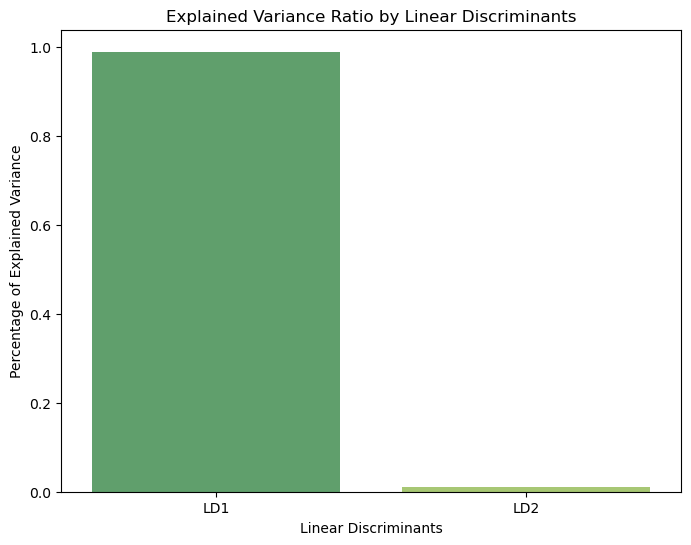

In [10]:
# Explained Variance Ratio Plot
plt.figure(figsize=(8, 6))
# Adjusted to use 'lda' instead of 'lda_full' which is fitted on the entire dataset before.
sns.barplot(x=['LD1', 'LD2'], y=lda.explained_variance_ratio_, palette='summer')
plt.title('Explained Variance Ratio by Linear Discriminants')
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Linear Discriminants')
plt.show()

# Predict y

In [11]:
y_pred = lda.predict(X_test)

# 11. Confusion matrix and classification report

In [12]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)

Confusion Matrix:
[[29  0  0]
 [ 0 23  0]
 [ 0  1 22]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        29
  versicolor       0.96      1.00      0.98        23
   virginica       1.00      0.96      0.98        23

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



# 12. Confusion matrix

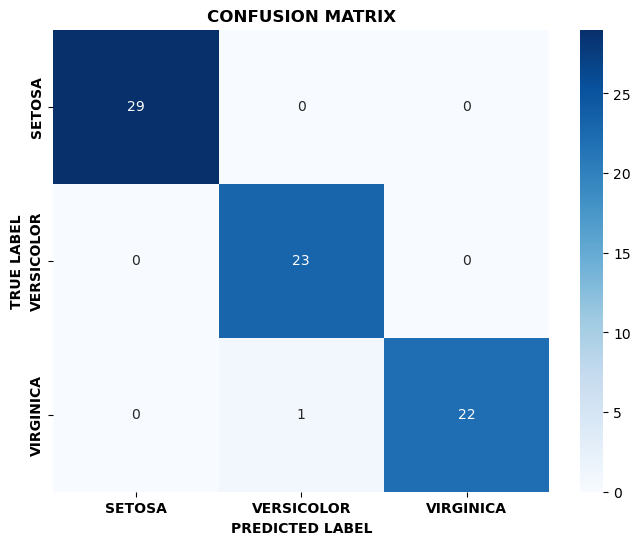

In [13]:
# confusion matrix

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=[label.upper() for label in lda.classes_], 
            yticklabels=[label.upper() for label in lda.classes_])
plt.title('CONFUSION MATRIX', fontweight='bold')
plt.ylabel('TRUE LABEL', fontweight='bold')
plt.xlabel('PREDICTED LABEL', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

# Note:

#Quadratic Discriminant Analysis using python
(Note: In this example, we demonstrate the coding procedure of Quadratic Discriminant Analysis (QDA) using the "Irish" dataset. However, it is important to mention that QDA assumes different covariance matrices for each class. Since Bartlett's test suggests equal variances for this dataset, Linear Discriminant Analysis (LDA) would technically be more appropriate here. QDA is presented solely for instructional purposes)

# *All steps prior to model fitting are the same for Quadratic Discriminant Analysis (QDA).*

# 9.3.2 Perform Quadratic Discriminant Analysis

# 1. Set up and fit a Quadratic Discriminant Analysis (QDA) model.

In [14]:
# Perform Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

# 2. Predict on the test set

In [15]:
# Predict on the test set
y_pred = qda.predict(X_test)

# 3. Confusion Matrix

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[29  0  0]
 [ 0 23  0]
 [ 0  2 21]]


# 4. Classification Report

In [17]:
# Classification Report
report = classification_report(y_test, y_pred, target_names=data.target_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        29
  versicolor       0.92      1.00      0.96        23
   virginica       1.00      0.91      0.95        23

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



# 5. Plot Confusion Matrix with Bold Labels and High DPI

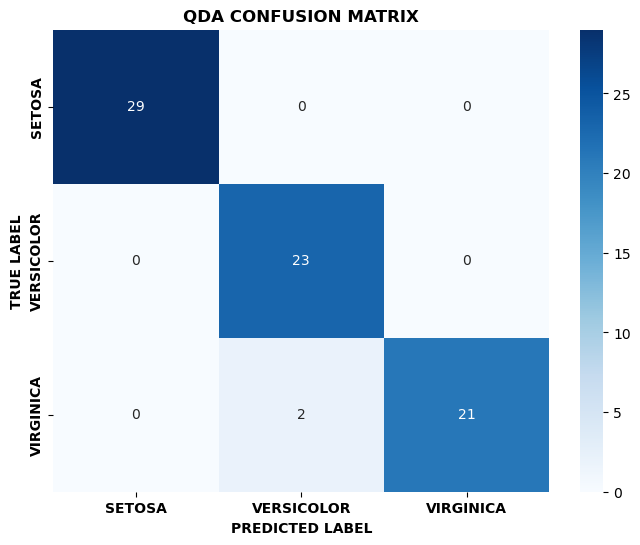

In [18]:
# Plot Confusion Matrix with Bold Labels and High DPI
plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=[label.upper() for label in data.target_names], 
            yticklabels=[label.upper() for label in data.target_names])
plt.title('QDA CONFUSION MATRIX', fontweight='bold')
plt.ylabel('TRUE LABEL', fontweight='bold')
plt.xlabel('PREDICTED LABEL', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()